# Traffic-Noise Denoiser for CNN14 / ESC-50 — U-Net (STFT-magnitude masking)

This notebook is **standalone**: it reloads your fine-tuned CNN14 checkpoint and the
ESC-50 fold setup from your original experiment, trains a small **U-Net spectral-mask
denoiser** on **fold 4 traffic noise** (synthetic SNR range), and evaluates it against:

- Clean baseline
- Noisy (traffic noise, no denoising)
- MMSE-LSA / IMCRA (your existing classical baseline — optional, included for comparison)
- **U-Net denoised**

Pipeline per clip: `load → add traffic noise (target SNR) → U-Net mask in STFT domain
→ iSTFT → log-mel → normalize → CNN14 → prediction`

**Training data**: ESC-50 folds {1,2,3,5} (your existing train/dev split). Fold 4 stays
sealed as the test set — same protocol as your original experiment.

**Architecture**: 3-level U-Net operating on STFT magnitude spectrograms. Predicts a
soft mask `M(f,t) ∈ [0,1]`, applied to noisy magnitude; noisy phase is reused for iSTFT.
This keeps the denoiser in the same domain as your classical MMSE-LSA/IMCRA baselines
(apples-to-apples comparison) and produces a clean **waveform**, so the existing
`wav_to_logmel → normalize → CNN14` pipeline is reused unchanged.


## Cell 1 — Mount Drive & GPU check

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU detected — training will be slow. Runtime > Change runtime type > GPU")


Mounted at /content/drive
Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


## Cell 2 — Configuration (must match your original experiment exactly)

In [2]:
import os, json, random
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# ── Paths (EDIT IF NEEDED) ────────────────────────────────────────────────────
DATA_PATH   = "/content/drive/MyDrive/DSP Project/esc50_data/ESC-50-master"
DRIVE_BASE  = Path(DATA_PATH)
AUDIO_DIR   = DRIVE_BASE / "audio"
META_PATH   = DRIVE_BASE / "meta" / "esc50.csv"

# Your fine-tuned CNN14 checkpoint (the model you already trained on clean ESC-50)
FINETUNED_CKPT = Path(
    "/content/drive/MyDrive/DSP Project/overfitting_check/models/phase3_best.pth"
)

# Real-world traffic noise recording (same file used in your original notebook)
PROJECT_DIR         = "/content/drive/MyDrive/DSP Project"
REAL_NOISE_FILENAME = "traffic_noise.wav"
REAL_NOISE_PATH     = os.path.join(PROJECT_DIR, REAL_NOISE_FILENAME)

# ── Output folder for this experiment ──────────────────────────────────────
OUT_DIR     = Path("/content/drive/MyDrive/DSP Project/traffic_denoiser_unet")
OUT_MODELS  = OUT_DIR / "models"
OUT_LOGS    = OUT_DIR / "logs"
OUT_RESULTS = OUT_DIR / "results"
for _d in [OUT_MODELS, OUT_LOGS, OUT_RESULTS]:
    _d.mkdir(parents=True, exist_ok=True)

# ── Splits — same protocol as original notebook ────────────────────────────
OUTER_TEST_FOLD = 4
INNER_VAL_FRAC  = 0.10
INNER_VAL_SEED  = 42
SEED            = 42

# ── Audio / spectrogram settings (MUST match training exactly) ─────────────
SR_ORIGINAL  = 44_100
SR_MODEL     = 32_000
CLIP_SAMPLES = 160_000
CLIP_DURATION = 5.0

N_FFT       = 1024
HOP_LENGTH  = 320
WIN_LENGTH  = 1024
N_MELS      = 64
FMIN        = 50
FMAX        = 14_000

NUM_CLASSES = 50
DROPOUT_CLASSIFIER = 0.5

# ── Normalisation stats (same hardcoded values as original notebook) ───────
_DEV_FOLD_STATS = {
    1: (-12.7464, 21.1534),
    2: (-12.8910, 21.3112),
    3: (-12.5737, 21.1908),
    5: (-12.8443, 21.5056),
}
mean = float(np.mean([v[0] for v in _DEV_FOLD_STATS.values()]))
std  = float(np.mean([v[1] for v in _DEV_FOLD_STATS.values()]))
print(f"Normalisation: mean={mean:.4f}  std={std:.4f}")

# ── Traffic noise SNR levels ────────────────────────────────────────────────
TRAFFIC_SNR_TRAIN = [20, 15, 10, 5, 0,-5,-10,-15,-20]   # SNRs used to generate training pairs
TRAFFIC_SNR_EVAL  = [20, 15, 10, 5, 0,-5,-10,-15,-20]   # SNRs used for final evaluation

# ── U-Net training hyperparameters ──────────────────────────────────────────
UNET_EPOCHS      = 25
UNET_LR          = 1e-3
UNET_BATCH_SIZE  = 8
UNET_WEIGHT_DECAY = 1e-5
EARLY_STOP_PATIENCE = 5

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Output folder: {OUT_DIR}")
print(f"Device: {device}")


Normalisation: mean=-12.7639  std=21.2903
Output folder: /content/drive/MyDrive/DSP Project/traffic_denoiser_unet
Device: cuda


## Cell 3 — Dataset utilities (load, resample, fix length, mel transform, splits)

In [3]:
def load_and_resample(path: str) -> torch.Tensor:
    waveform, sr = torchaudio.load(path)
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != SR_MODEL:
        waveform = T.Resample(orig_freq=sr, new_freq=SR_MODEL)(waveform)
    return waveform


def fix_clip_length(waveform: torch.Tensor) -> torch.Tensor:
    n      = waveform.shape[-1]
    target = CLIP_SAMPLES
    if n < target:
        waveform = torch.nn.functional.pad(waveform, (0, target - n))
    elif n > target:
        start    = (n - target) // 2
        waveform = waveform[:, start: start + target]
    return waveform


def load_wav_np(file_path):
    '''Load audio -> numpy (1, CLIP_LEN), same as training pipeline.'''
    wav = fix_clip_length(load_and_resample(file_path))
    return wav.numpy()


_MEL_XFORM = torch.nn.Sequential(
    T.MelSpectrogram(
        sample_rate=SR_MODEL, n_fft=N_FFT, win_length=WIN_LENGTH,
        hop_length=HOP_LENGTH, f_min=FMIN, f_max=FMAX,
        n_mels=N_MELS, power=2.0,
    ),
    T.AmplitudeToDB(stype="power", top_db=80.0),
)


def wav_to_logmel(wav_np):
    '''wav_np: (1, L) numpy -> (1, N_MELS, T) numpy.'''
    with torch.no_grad():
        t = torch.tensor(wav_np, dtype=torch.float32)
        return _MEL_XFORM(t).numpy()


def load_metadata() -> pd.DataFrame:
    df = pd.read_csv(META_PATH)
    df["file_path"] = df["filename"].apply(lambda f: str(AUDIO_DIR / f))
    return df


def build_label_map(df: pd.DataFrame) -> dict:
    cats = sorted(df["category"].unique())
    return {cat: idx for idx, cat in enumerate(cats)}


from sklearn.model_selection import train_test_split

def make_inner_split(df_dev: pd.DataFrame, val_frac: float = INNER_VAL_FRAC,
                      seed: int = INNER_VAL_SEED):
    df_train, df_val = train_test_split(
        df_dev, test_size=val_frac, random_state=seed,
        stratify=df_dev["category"],
    )
    return df_train.reset_index(drop=True), df_val.reset_index(drop=True)


df            = load_metadata()
label_to_idx  = build_label_map(df)

df_test_outer = df[df["fold"] == OUTER_TEST_FOLD].reset_index(drop=True)
df_dev        = df[df["fold"] != OUTER_TEST_FOLD].reset_index(drop=True)
df_train_inner, df_val_inner = make_inner_split(df_dev)

print(f"Dataset       : {len(df)} clips | {len(label_to_idx)} classes")
print(f"Train (folds 1,2,3,5, 90%) : {len(df_train_inner)} clips  -> U-Net training")
print(f"Val   (folds 1,2,3,5, 10%) : {len(df_val_inner)} clips    -> U-Net early stopping")
print(f"Test  (fold {OUTER_TEST_FOLD}, sealed)        : {len(df_test_outer)} clips    -> final evaluation")


Dataset       : 2000 clips | 50 classes
Train (folds 1,2,3,5, 90%) : 1440 clips  -> U-Net training
Val   (folds 1,2,3,5, 10%) : 160 clips    -> U-Net early stopping
Test  (fold 4, sealed)        : 400 clips    -> final evaluation


## Cell 4 — CNN14 model definition + load your fine-tuned checkpoint

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.bn2   = nn.BatchNorm2d(out_ch)

    def forward(self, x, pool_size=(2, 2), pool_type="avg"):
        x = F.relu_(self.bn1(self.conv1(x)))
        x = F.relu_(self.bn2(self.conv2(x)))
        if pool_type == "max":
            x = F.max_pool2d(x, pool_size)
        elif pool_type == "avg":
            x = F.avg_pool2d(x, pool_size)
        elif pool_type == "avg+max":
            x = F.avg_pool2d(x, pool_size) + F.max_pool2d(x, pool_size)
        return x


class Cnn14Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.bn0         = nn.BatchNorm2d(64)
        self.conv_block1 = ConvBlock(1,    64)
        self.conv_block2 = ConvBlock(64,  128)
        self.conv_block3 = ConvBlock(128, 256)
        self.conv_block4 = ConvBlock(256, 512)
        self.conv_block5 = ConvBlock(512, 1024)
        self.conv_block6 = ConvBlock(1024, 2048)
        self.fc1         = nn.Linear(2048, 2048, bias=True)

    def forward(self, x):
        x = x.transpose(2, 3)
        x = x.transpose(1, 3)
        x = self.bn0(x)
        x = x.transpose(1, 3)
        for blk in [self.conv_block1, self.conv_block2,
                    self.conv_block3, self.conv_block4, self.conv_block5]:
            x = F.dropout(blk(x, pool_size=(2, 2), pool_type="avg"),
                          p=0.2, training=self.training)
        x = F.dropout(self.conv_block6(x, pool_size=(1, 1), pool_type="avg"),
                      p=0.2, training=self.training)
        x = (torch.mean(x, dim=3) + torch.amax(x, dim=3)) / 2
        x = torch.mean(x, dim=2)
        x = F.dropout(x, p=0.5, training=self.training)
        x = F.relu_(self.fc1(x))
        x = F.dropout(x, p=0.5, training=self.training)
        return x


class CNN14ESC50(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone   = Cnn14Backbone()
        self.classifier = nn.Sequential(
            nn.Dropout(p=DROPOUT_CLASSIFIER),
            nn.Linear(2048, NUM_CLASSES, bias=True),
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))


model = CNN14ESC50().to(device)
state = torch.load(FINETUNED_CKPT, map_location=device)
model.load_state_dict(state)
model.eval()
print(f"Loaded fine-tuned CNN14 checkpoint: {FINETUNED_CKPT}")


def infer_wav(wav_np):
    '''Full inference pipeline on a raw waveform numpy array -> predicted class index.'''
    spec = torch.tensor(wav_to_logmel(wav_np), dtype=torch.float32)
    spec = (spec - mean) / std
    spec = spec.unsqueeze(0).to(device)
    with torch.no_grad():
        return model(spec).argmax(dim=1).item()


Loaded fine-tuned CNN14 checkpoint: /content/drive/MyDrive/DSP Project/overfitting_check/models/phase3_best.pth


## Cell 5 — Load traffic noise + noise mixing

In [6]:
if os.path.exists(REAL_NOISE_PATH):
    _real_noise_wav, _sr_in = torchaudio.load(REAL_NOISE_PATH)
    if _sr_in != SR_MODEL:
        _real_noise_wav = torchaudio.functional.resample(_real_noise_wav, _sr_in, SR_MODEL)
    if _real_noise_wav.shape[0] > 1:
        _real_noise_wav = _real_noise_wav.mean(dim=0, keepdim=True)
    _raw_noise = _real_noise_wav.squeeze(0).numpy().astype(np.float32)
    print(f"Loaded traffic noise: {REAL_NOISE_PATH}")
    print(f"  Duration: {len(_raw_noise) / SR_MODEL:.1f}s | Samples: {len(_raw_noise)}")
else:
    raise FileNotFoundError(
        f"Traffic noise file not found at {REAL_NOISE_PATH}. "
        "Upload it to your Drive project folder before continuing."
    )


def _fit_noise_to_length(noise, length, rng):
    if len(noise) < length:
        reps  = int(np.ceil(length / len(noise)))
        noise = np.tile(noise, reps)
    if len(noise) > length:
        max_start = len(noise) - length
        start     = int(rng.integers(0, max_start + 1))
        noise     = noise[start:start + length]
    return noise[:length]


def add_real_noise(wav_np, target_snr_db, noise_clip=None, rng=None):
    '''Mix traffic noise into wav_np (1, L) at target SNR. Same convention as
    the white/Gaussian noise generators in the original notebook.'''
    if noise_clip is None:
        noise_clip = _raw_noise
    if rng is None:
        rng = np.random.default_rng()

    sig   = wav_np[0]
    noise = _fit_noise_to_length(noise_clip, len(sig), rng)

    p_sig = np.mean(sig ** 2)
    p_n   = p_sig / (10 ** (target_snr_db / 10.0))
    noise = noise * np.sqrt(p_n / (np.mean(noise ** 2) + 1e-10))

    return np.clip(sig + noise, -1.0, 1.0).astype(np.float32)[np.newaxis, :]


def measure_snr_output(clean, processed):
    p_sig  = np.mean(clean ** 2)
    p_dist = np.mean((processed - clean) ** 2)
    return 10.0 * np.log10(p_sig / (p_dist + 1e-12)) if p_dist > 1e-12 else float('inf')


def measure_snr_input(clean, noisy):
    p_sig = np.mean(clean ** 2)
    p_noi = np.mean((noisy - clean) ** 2)
    return 10.0 * np.log10(p_sig / (p_noi + 1e-12)) if p_noi > 1e-12 else float('inf')


print("Traffic noise mixing utilities ready")


FileNotFoundError: Traffic noise file not found at /content/drive/MyDrive/DSP Project/traffic_noise.wav. Upload it to your Drive project folder before continuing.

## Cell 6 — STFT / iSTFT helpers (torch, batched, differentiable)

In [7]:
if os.path.exists(REAL_NOISE_PATH):
    print(f"Found traffic noise at: {REAL_NOISE_PATH}")
else:
    print(f"Traffic noise not found at: {REAL_NOISE_PATH}")
    print("Please upload your traffic_noise.wav file now...")
    from google.colab import files
    uploaded = files.upload()
    uploaded_filename = list(uploaded.keys())[0]

    # Save it to the expected Drive location for future runs
    os.makedirs(os.path.dirname(REAL_NOISE_PATH), exist_ok=True)
    shutil.copy(uploaded_filename, REAL_NOISE_PATH)
    print(f"Saved uploaded file -> {REAL_NOISE_PATH}")

_real_noise_wav, _sr_in = torchaudio.load(REAL_NOISE_PATH)
if _sr_in != SR_MODEL:
    _real_noise_wav = torchaudio.functional.resample(_real_noise_wav, _sr_in, SR_MODEL)
if _real_noise_wav.shape[0] > 1:
    _real_noise_wav = _real_noise_wav.mean(dim=0, keepdim=True)
_raw_noise = _real_noise_wav.squeeze(0).numpy().astype(np.float32)
print(f"Loaded traffic noise: {REAL_NOISE_PATH}")
print(f"  Duration: {len(_raw_noise) / SR_MODEL:.1f}s | Samples: {len(_raw_noise)}")


def _fit_noise_to_length(noise, length, rng):
    if len(noise) < length:
        reps  = int(np.ceil(length / len(noise)))
        noise = np.tile(noise, reps)
    if len(noise) > length:
        max_start = len(noise) - length
        start     = int(rng.integers(0, max_start + 1))
        noise     = noise[start:start + length]
    return noise[:length]


def add_real_noise(wav_np, target_snr_db, noise_clip=None, rng=None):
    if noise_clip is None:
        noise_clip = _raw_noise
    if rng is None:
        rng = np.random.default_rng()

    sig   = wav_np[0]
    noise = _fit_noise_to_length(noise_clip, len(sig), rng)

    p_sig = np.mean(sig ** 2)
    p_n   = p_sig / (10 ** (target_snr_db / 10.0))
    noise = noise * np.sqrt(p_n / (np.mean(noise ** 2) + 1e-10))

    return np.clip(sig + noise, -1.0, 1.0).astype(np.float32)[np.newaxis, :]


def measure_snr_output(clean, processed):
    p_sig  = np.mean(clean ** 2)
    p_dist = np.mean((processed - clean) ** 2)
    return 10.0 * np.log10(p_sig / (p_dist + 1e-12)) if p_dist > 1e-12 else float('inf')


def measure_snr_input(clean, noisy):
    p_sig = np.mean(clean ** 2)
    p_noi = np.mean((noisy - clean) ** 2)
    return 10.0 * np.log10(p_sig / (p_noi + 1e-12)) if p_noi > 1e-12 else float('inf')


print("Traffic noise mixing utilities ready")

Traffic noise not found at: /content/drive/MyDrive/DSP Project/traffic_noise.wav
Please upload your traffic_noise.wav file now...


Saving 478572__pesticidex__traffic-sounds002 (mp3cut.net).wav to 478572__pesticidex__traffic-sounds002 (mp3cut.net).wav


NameError: name 'shutil' is not defined

In [8]:
import shutil

if os.path.exists(REAL_NOISE_PATH):
    print(f"Found traffic noise at: {REAL_NOISE_PATH}")
else:
    print(f"Traffic noise not found at: {REAL_NOISE_PATH}")
    print("Please upload your traffic_noise.wav file now...")
    from google.colab import files
    uploaded = files.upload()
    uploaded_filename = list(uploaded.keys())[0]

    # Save it to the expected Drive location for future runs
    os.makedirs(os.path.dirname(REAL_NOISE_PATH), exist_ok=True)
    shutil.copy(uploaded_filename, REAL_NOISE_PATH)
    print(f"Saved uploaded file -> {REAL_NOISE_PATH}")

_real_noise_wav, _sr_in = torchaudio.load(REAL_NOISE_PATH)
if _sr_in != SR_MODEL:
    _real_noise_wav = torchaudio.functional.resample(_real_noise_wav, _sr_in, SR_MODEL)
if _real_noise_wav.shape[0] > 1:
    _real_noise_wav = _real_noise_wav.mean(dim=0, keepdim=True)
_raw_noise = _real_noise_wav.squeeze(0).numpy().astype(np.float32)
print(f"Loaded traffic noise: {REAL_NOISE_PATH}")
print(f"  Duration: {len(_raw_noise) / SR_MODEL:.1f}s | Samples: {len(_raw_noise)}")


def _fit_noise_to_length(noise, length, rng):
    if len(noise) < length:
        reps  = int(np.ceil(length / len(noise)))
        noise = np.tile(noise, reps)
    if len(noise) > length:
        max_start = len(noise) - length
        start     = int(rng.integers(0, max_start + 1))
        noise     = noise[start:start + length]
    return noise[:length]


def add_real_noise(wav_np, target_snr_db, noise_clip=None, rng=None):
    if noise_clip is None:
        noise_clip = _raw_noise
    if rng is None:
        rng = np.random.default_rng()

    sig   = wav_np[0]
    noise = _fit_noise_to_length(noise_clip, len(sig), rng)

    p_sig = np.mean(sig ** 2)
    p_n   = p_sig / (10 ** (target_snr_db / 10.0))
    noise = noise * np.sqrt(p_n / (np.mean(noise ** 2) + 1e-10))

    return np.clip(sig + noise, -1.0, 1.0).astype(np.float32)[np.newaxis, :]


def measure_snr_output(clean, processed):
    p_sig  = np.mean(clean ** 2)
    p_dist = np.mean((processed - clean) ** 2)
    return 10.0 * np.log10(p_sig / (p_dist + 1e-12)) if p_dist > 1e-12 else float('inf')


def measure_snr_input(clean, noisy):
    p_sig = np.mean(clean ** 2)
    p_noi = np.mean((noisy - clean) ** 2)
    return 10.0 * np.log10(p_sig / (p_noi + 1e-12)) if p_noi > 1e-12 else float('inf')


print("Traffic noise mixing utilities ready")

Traffic noise not found at: /content/drive/MyDrive/DSP Project/traffic_noise.wav
Please upload your traffic_noise.wav file now...


Saving 478572__pesticidex__traffic-sounds002 (mp3cut.net).wav to 478572__pesticidex__traffic-sounds002 (mp3cut.net) (1).wav
Saved uploaded file -> /content/drive/MyDrive/DSP Project/traffic_noise.wav
Loaded traffic noise: /content/drive/MyDrive/DSP Project/traffic_noise.wav
  Duration: 5.1s | Samples: 161983
Traffic noise mixing utilities ready


In [9]:
# These mirror the numpy STFT/iSTFT from the original notebook but are
# torch-native, batched, and differentiable so they can sit inside the
# training loop / autograd graph.

_WINDOW = torch.hann_window(N_FFT, periodic=True)

def stft_torch(wav, device=None):
    '''wav: (B, L) torch tensor -> complex STFT (B, F, T).'''
    window = _WINDOW.to(wav.device if device is None else device)
    return torch.stft(
        wav, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
        window=window, return_complex=True, center=True,
    )


def istft_torch(stft_c, length, device=None):
    '''stft_c: complex (B, F, T) -> waveform (B, L).'''
    window = _WINDOW.to(stft_c.device if device is None else device)
    return torch.istft(
        stft_c, n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH,
        window=window, center=True, length=length,
    )


print("STFT/iSTFT helpers ready")
print(f"  n_fft={N_FFT}  hop={HOP_LENGTH}  win={WIN_LENGTH}")
print(f"  freq bins = {N_FFT // 2 + 1}, frames @ {CLIP_SAMPLES} samples = "
      f"{stft_torch(torch.zeros(1, CLIP_SAMPLES)).shape[-1]}")


STFT/iSTFT helpers ready
  n_fft=1024  hop=320  win=1024
  freq bins = 513, frames @ 160000 samples = 501


## Cell 7 — U-Net spectral mask denoiser

3 encoder / 3 decoder levels with skip connections, operating on the STFT
magnitude spectrogram (in dB, normalized). Output is a single-channel sigmoid
mask `M(f,t) in [0,1]`, applied to the **noisy linear magnitude**; the noisy
phase is reused for reconstruction. Padding ensures arbitrary (F,T) shapes work
via crop/pad to the nearest multiple of 8.

In [10]:
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class DenoiseUNet(nn.Module):
    '''Small 3-level U-Net predicting a [0,1] spectral mask.

    Input : (B, 1, F, T)  -- log-magnitude STFT, normalized
    Output: (B, 1, F, T)  -- mask in [0,1]
    '''
    def __init__(self, base_ch=16):
        super().__init__()
        c = base_ch
        # Encoder
        self.enc1 = nn.Sequential(ConvBNReLU(1,   c),   ConvBNReLU(c,   c))
        self.enc2 = nn.Sequential(ConvBNReLU(c,   c*2), ConvBNReLU(c*2, c*2))
        self.enc3 = nn.Sequential(ConvBNReLU(c*2, c*4), ConvBNReLU(c*4, c*4))
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = nn.Sequential(ConvBNReLU(c*4, c*8), ConvBNReLU(c*8, c*8))

        # Decoder
        self.up3  = nn.ConvTranspose2d(c*8, c*4, kernel_size=2, stride=2)
        self.dec3 = nn.Sequential(ConvBNReLU(c*8, c*4), ConvBNReLU(c*4, c*4))

        self.up2  = nn.ConvTranspose2d(c*4, c*2, kernel_size=2, stride=2)
        self.dec2 = nn.Sequential(ConvBNReLU(c*4, c*2), ConvBNReLU(c*2, c*2))

        self.up1  = nn.ConvTranspose2d(c*2, c,   kernel_size=2, stride=2)
        self.dec1 = nn.Sequential(ConvBNReLU(c*2, c),   ConvBNReLU(c, c))

        self.out_conv = nn.Conv2d(c, 1, kernel_size=1)

    def forward(self, x):
        # x: (B, 1, F, T) -- pad F,T to multiples of 8 for clean up/downsampling
        B, C, Fdim, Tdim = x.shape
        pad_f = (8 - Fdim % 8) % 8
        pad_t = (8 - Tdim % 8) % 8
        x_p = F.pad(x, (0, pad_t, 0, pad_f))

        e1 = self.enc1(x_p)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        mask = torch.sigmoid(self.out_conv(d1))
        # crop back to original (F, T)
        mask = mask[:, :, :Fdim, :Tdim]
        return mask


_unet_test = DenoiseUNet().to(device)
_test_in   = torch.randn(2, 1, N_FFT // 2 + 1, 501).to(device)
with torch.no_grad():
    _test_out = _unet_test(_test_in)
print(f"U-Net OK -- input {tuple(_test_in.shape)} -> mask {tuple(_test_out.shape)}")
n_params = sum(p.numel() for p in _unet_test.parameters())
print(f"U-Net parameters: {n_params:,}")
del _unet_test, _test_in, _test_out


U-Net OK -- input (2, 1, 513, 501) -> mask (2, 1, 513, 501)
U-Net parameters: 482,449


## Cell 8 — Training dataset: (noisy STFT, clean waveform) pairs

For each training clip, traffic noise is mixed at a randomly-chosen SNR (from
`TRAFFIC_SNR_TRAIN`) with a random crop offset of the traffic recording each
time `__getitem__` is called -- this gives the U-Net broad exposure to traffic
noise at different levels and temporal segments.

In [11]:
class TrafficDenoiseDataset(Dataset):
    '''Returns (noisy_logmag, noisy_phase, clean_wav, noisy_wav) per clip.

    noisy_logmag : (1, F, T) normalized log-magnitude -- U-Net input
    noisy_phase  : (F, T) complex unit-phase -- used for reconstruction
    clean_wav    : (L,) target waveform for the loss
    '''
    def __init__(self, df, snr_levels, seed=None):
        self.df = df.reset_index(drop=True)
        self.snr_levels = snr_levels
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clean_np = load_wav_np(row["file_path"])          # (1, L)

        snr = self.rng.choice(self.snr_levels)
        noisy_np = add_real_noise(clean_np, float(snr), rng=self.rng)  # (1, L)

        clean_wav = torch.tensor(clean_np[0], dtype=torch.float32)
        noisy_wav = torch.tensor(noisy_np[0], dtype=torch.float32)
        return noisy_wav, clean_wav


def collate_pad(batch):
    # all clips are already CLIP_SAMPLES long (fix_clip_length), so just stack
    noisy = torch.stack([b[0] for b in batch], dim=0)
    clean = torch.stack([b[1] for b in batch], dim=0)
    return noisy, clean


train_ds = TrafficDenoiseDataset(df_train_inner, TRAFFIC_SNR_TRAIN, seed=SEED)
val_ds   = TrafficDenoiseDataset(df_val_inner,   TRAFFIC_SNR_TRAIN, seed=SEED + 1)

train_loader = DataLoader(train_ds, batch_size=UNET_BATCH_SIZE, shuffle=True,
                           collate_fn=collate_pad, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=UNET_BATCH_SIZE, shuffle=False,
                           collate_fn=collate_pad, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Training SNRs: {TRAFFIC_SNR_TRAIN} dB (randomly sampled per clip per epoch)")


Train batches: 180 | Val batches: 20
Training SNRs: [20, 15, 10, 5, 0] dB (randomly sampled per clip per epoch)


## Cell 9 — Training loop

Loss = L1 loss on log-mel spectrograms (clean vs. denoised), the same
representation CNN14 consumes -- so the denoiser is optimized for what the
classifier actually sees, not raw waveform fidelity.

Each step:
1. STFT the noisy waveform -> magnitude (log-scaled, normalized) + phase
2. U-Net predicts mask -> apply to noisy linear magnitude
3. iSTFT (masked magnitude + noisy phase) -> denoised waveform
4. log-mel(denoised) vs log-mel(clean) -> L1 loss


In [12]:
EPS = 1e-8

def wav_to_mag_phase(wav):
    '''wav: (B, L) -> (mag (B,F,T), phase_complex_unit (B,F,T))'''
    spec = stft_torch(wav)               # complex (B, F, T)
    mag  = torch.abs(spec)
    phase = spec / (mag + EPS)           # unit-magnitude complex
    return mag, phase


def logmag_norm(mag):
    '''log-magnitude, roughly normalized to ~[-1, 3] range for network input.'''
    return torch.log1p(mag)


_MEL_XFORM_T = T.MelSpectrogram(
    sample_rate=SR_MODEL, n_fft=N_FFT, win_length=WIN_LENGTH,
    hop_length=HOP_LENGTH, f_min=FMIN, f_max=FMAX, n_mels=N_MELS, power=2.0,
).to(device)
_AMP_TO_DB_T = T.AmplitudeToDB(stype="power", top_db=80.0).to(device)

def wav_to_logmel_torch(wav):
    '''wav: (B, L) -> (B, N_MELS, T) log-mel, batched/differentiable.'''
    mel = _MEL_XFORM_T(wav)
    return _AMP_TO_DB_T(mel)


unet = DenoiseUNet().to(device)
optimizer = torch.optim.AdamW(unet.parameters(), lr=UNET_LR,
                               weight_decay=UNET_WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNET_EPOCHS)


def denoise_wav_batch(unet, noisy_wav):
    '''noisy_wav: (B, L) -> denoised_wav (B, L)'''
    mag, phase = wav_to_mag_phase(noisy_wav)
    x_in = logmag_norm(mag).unsqueeze(1)        # (B, 1, F, T)
    mask = unet(x_in).squeeze(1)                # (B, F, T)
    denoised_mag = mask * mag
    denoised_spec = denoised_mag * phase        # reapply noisy phase
    denoised_wav = istft_torch(denoised_spec, length=noisy_wav.shape[-1])
    return denoised_wav


def run_epoch(unet, loader, optimizer=None):
    is_train = optimizer is not None
    unet.train() if is_train else unet.eval()
    total_loss, n_batches = 0.0, 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for noisy_wav, clean_wav in loader:
            noisy_wav = noisy_wav.to(device)
            clean_wav = clean_wav.to(device)

            denoised_wav = denoise_wav_batch(unet, noisy_wav)

            logmel_denoised = wav_to_logmel_torch(denoised_wav)
            logmel_clean    = wav_to_logmel_torch(clean_wav)
            loss = F.l1_loss(logmel_denoised, logmel_clean)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(unet.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

    return total_loss / max(n_batches, 1)


best_val = float("inf")
best_path = OUT_MODELS / "unet_best.pth"
patience_counter = 0

for epoch in range(1, UNET_EPOCHS + 1):
    train_loss = run_epoch(unet, train_loader, optimizer)
    val_loss   = run_epoch(unet, val_loader, optimizer=None)
    scheduler.step()

    print(f"Epoch {epoch:03d}/{UNET_EPOCHS} | "
          f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"lr={scheduler.get_last_lr()[0]:.2e}")

    if val_loss < best_val:
        best_val = val_loss
        patience_counter = 0
        torch.save(unet.state_dict(), best_path)
        print(f"  -> saved new best (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"  Early stopping at epoch {epoch} (no improvement for "
                  f"{EARLY_STOP_PATIENCE} epochs)")
            break

unet.load_state_dict(torch.load(best_path, map_location=device))
unet.eval()
print(f"\nLoaded best U-Net checkpoint (val_loss={best_val:.4f})")


Epoch 001/25 | train_loss=6.7830 | val_loss=6.2637 | lr=9.96e-04
  -> saved new best (val_loss=6.2637)
Epoch 002/25 | train_loss=5.3146 | val_loss=5.0194 | lr=9.84e-04
  -> saved new best (val_loss=5.0194)
Epoch 003/25 | train_loss=4.8102 | val_loss=6.0059 | lr=9.65e-04
Epoch 004/25 | train_loss=4.3424 | val_loss=3.7627 | lr=9.38e-04
  -> saved new best (val_loss=3.7627)
Epoch 005/25 | train_loss=3.9013 | val_loss=3.6551 | lr=9.05e-04
  -> saved new best (val_loss=3.6551)
Epoch 006/25 | train_loss=3.5898 | val_loss=7.0354 | lr=8.64e-04
Epoch 007/25 | train_loss=3.2679 | val_loss=3.4756 | lr=8.19e-04
  -> saved new best (val_loss=3.4756)
Epoch 008/25 | train_loss=3.1901 | val_loss=3.3380 | lr=7.68e-04
  -> saved new best (val_loss=3.3380)
Epoch 009/25 | train_loss=3.0287 | val_loss=3.5237 | lr=7.13e-04
Epoch 010/25 | train_loss=2.8838 | val_loss=4.0031 | lr=6.55e-04
Epoch 011/25 | train_loss=2.8083 | val_loss=7.3707 | lr=5.94e-04
Epoch 012/25 | train_loss=2.7603 | val_loss=3.0376 | lr=5

## Cell 10 — Inference helper for U-Net denoising (numpy in/out)

Mirrors `infer_wav` / `mmse_lsa_denoise` signatures from the original notebook
so this drops directly into the same evaluation pattern.

In [13]:
@torch.no_grad()
def unet_denoise(noisy_np):
    '''noisy_np: (1, L) numpy -> denoised (1, L) numpy, via U-Net spectral mask.'''
    wav = torch.tensor(noisy_np, dtype=torch.float32, device=device)  # (1, L)
    denoised = denoise_wav_batch(unet, wav)                            # (1, L)
    return denoised.cpu().numpy().astype(np.float32)


print("U-Net inference helper ready")


U-Net inference helper ready


## Cell 12b — Gaussian / White noise generators (for multi-condition comparison)

These mirror `add_real_noise` but inject synthetic **Gaussian** and **White**
noise at the same target SNR, so the U-Net (trained only on traffic noise) can
be evaluated for generalization to unseen noise types.


In [ ]:
def add_gaussian_noise(wav_np, target_snr_db, rng=None):
    '''Mix Gaussian (normal) noise into wav_np (1, L) at target SNR.'''
    if rng is None:
        rng = np.random.default_rng()

    sig   = wav_np[0]
    noise = rng.normal(0.0, 1.0, size=sig.shape).astype(np.float32)

    p_sig = np.mean(sig ** 2)
    p_n   = p_sig / (10 ** (target_snr_db / 10.0))
    noise = noise * np.sqrt(p_n / (np.mean(noise ** 2) + 1e-10))

    return np.clip(sig + noise, -1.0, 1.0).astype(np.float32)[np.newaxis, :]


def add_white_noise(wav_np, target_snr_db, rng=None):
    '''Mix uniform white noise into wav_np (1, L) at target SNR.'''
    if rng is None:
        rng = np.random.default_rng()

    sig   = wav_np[0]
    noise = rng.uniform(-1.0, 1.0, size=sig.shape).astype(np.float32)

    p_sig = np.mean(sig ** 2)
    p_n   = p_sig / (10 ** (target_snr_db / 10.0))
    noise = noise * np.sqrt(p_n / (np.mean(noise ** 2) + 1e-10))

    return np.clip(sig + noise, -1.0, 1.0).astype(np.float32)[np.newaxis, :]


print("Gaussian / White noise mixing utilities ready")


## Cell 12c — Multi-run evaluation (5 runs) for Traffic, Gaussian, White, and Clean

Repeats the fold-4 evaluation **N_RUNS = 5 times**, each with a different RNG
seed (so the noise realizations and crops differ per run), across:

- **Clean** (no noise, no denoising)
- **Traffic** noise, U-Net-denoised, per SNR
- **Gaussian** noise, U-Net-denoised, per SNR
- **White** noise, U-Net-denoised, per SNR

For each (condition, SNR) we collect per-run aggregate metrics
(accuracy, SNR-in, SNR-out, SNR improvement). This gives the
**mean ± std across runs** needed for the results table, plus paired
significance tests between Noisy vs. U-Net.


In [ ]:
N_RUNS = 5

NOISE_GENERATORS = {
    "traffic":  add_real_noise,
    "gaussian": add_gaussian_noise,
    "white":    add_white_noise,
}

# Per-run results, keyed by (condition, run_idx) -> dict of per-clip lists
multirun_records = []  # list of dict rows: one row per (run, condition, snr) summary
clean_run_acc = []     # clean accuracy per run (denoiser-independent, but kept per run for paired tests)

for run_idx in range(N_RUNS):
    run_seed = SEED + 1000 * run_idx + 100   # distinct seed per run
    eval_rng = np.random.default_rng(run_seed)

    run_res = {
        'filename'  : [],
        'true_idx'  : [],
        'pred_clean': [],
    }
    for cond in NOISE_GENERATORS:
        for snr in TRAFFIC_SNR_EVAL:
            run_res[f'pred_noisy_{cond}_{snr}dB']  = []
            run_res[f'pred_unet_{cond}_{snr}dB']   = []
            run_res[f'snr_in_{cond}_{snr}dB']      = []
            run_res[f'snr_out_unet_{cond}_{snr}dB'] = []

    for _, row in tqdm(df_test_outer.iterrows(), total=len(df_test_outer),
                        desc=f"Run {run_idx+1}/{N_RUNS}"):
        wav_np   = load_wav_np(row['file_path'])
        true_idx = label_to_idx[row['category']]

        run_res['filename'].append(row['filename'])
        run_res['true_idx'].append(true_idx)
        run_res['pred_clean'].append(infer_wav(wav_np))

        for cond, noise_fn in NOISE_GENERATORS.items():
            for snr in TRAFFIC_SNR_EVAL:
                noisy = noise_fn(wav_np, snr, rng=eval_rng)
                run_res[f'pred_noisy_{cond}_{snr}dB'].append(infer_wav(noisy))
                run_res[f'snr_in_{cond}_{snr}dB'].append(measure_snr_input(wav_np, noisy))

                denoised_unet = unet_denoise(noisy)
                run_res[f'pred_unet_{cond}_{snr}dB'].append(infer_wav(denoised_unet))
                run_res[f'snr_out_unet_{cond}_{snr}dB'].append(measure_snr_output(wav_np, denoised_unet))

    df_run = pd.DataFrame(run_res)
    df_run.to_csv(OUT_RESULTS / f"traffic_unet_eval_run{run_idx+1}.csv", index=False)

    # ---- per-run aggregates ----
    def _acc(col):
        return (df_run[col] == df_run['true_idx']).mean() * 100

    acc_clean_run = _acc('pred_clean')
    clean_run_acc.append(acc_clean_run)

    for cond in NOISE_GENERATORS:
        for snr in TRAFFIC_SNR_EVAL:
            acc_noisy = _acc(f'pred_noisy_{cond}_{snr}dB')
            acc_unet  = _acc(f'pred_unet_{cond}_{snr}dB')
            snr_in    = df_run[f'snr_in_{cond}_{snr}dB'].mean()
            snr_out   = df_run[f'snr_out_unet_{cond}_{snr}dB'].mean()

            multirun_records.append({
                'run'           : run_idx + 1,
                'condition'     : cond,
                'SNR_target'    : snr,
                'acc_clean'     : acc_clean_run,
                'acc_noisy'     : acc_noisy,
                'acc_unet'      : acc_unet,
                'unet_recovery' : acc_unet - acc_noisy,
                'snr_in'        : snr_in,
                'snr_out_unet'  : snr_out,
                'unet_snr_improve': snr_out - snr_in,
            })

    print(f"Run {run_idx+1}/{N_RUNS} done | clean_acc={acc_clean_run:.2f}%")

df_multirun = pd.DataFrame(multirun_records)
df_multirun.to_csv(OUT_RESULTS / "traffic_unet_multirun_raw.csv", index=False)
print(f"\nSaved raw multi-run results -> {OUT_RESULTS / 'traffic_unet_multirun_raw.csv'}")
print(f"Clean accuracy across {N_RUNS} runs: "
      f"{np.mean(clean_run_acc):.2f}% ± {np.std(clean_run_acc, ddof=1):.2f}%")


## Cell 12d — Summary: mean ± std per SNR per condition (Traffic / Gaussian / White)

Aggregates the `N_RUNS` runs above into a table reporting
**mean ± standard deviation** for accuracy (Noisy vs U-Net) and SNR
improvement, for every (condition, SNR) pair. Also reports the
**clean baseline** accuracy (mean ± std across runs).


In [ ]:
agg_rows = []
for cond in NOISE_GENERATORS:
    for snr in TRAFFIC_SNR_EVAL:
        sub = df_multirun[(df_multirun['condition'] == cond) & (df_multirun['SNR_target'] == snr)]

        agg_rows.append({
            'condition'        : cond,
            'SNR_target'       : snr,
            'acc_noisy_mean'   : sub['acc_noisy'].mean(),
            'acc_noisy_std'    : sub['acc_noisy'].std(ddof=1),
            'acc_unet_mean'    : sub['acc_unet'].mean(),
            'acc_unet_std'     : sub['acc_unet'].std(ddof=1),
            'recovery_mean'    : sub['unet_recovery'].mean(),
            'recovery_std'     : sub['unet_recovery'].std(ddof=1),
            'snr_in_mean'      : sub['snr_in'].mean(),
            'snr_in_std'       : sub['snr_in'].std(ddof=1),
            'snr_out_unet_mean': sub['snr_out_unet'].mean(),
            'snr_out_unet_std' : sub['snr_out_unet'].std(ddof=1),
            'snr_improve_mean' : sub['unet_snr_improve'].mean(),
            'snr_improve_std'  : sub['unet_snr_improve'].std(ddof=1),
        })

df_agg = pd.DataFrame(agg_rows)
df_agg.to_csv(OUT_RESULTS / "traffic_unet_multirun_summary.csv", index=False)

clean_mean = np.mean(clean_run_acc)
clean_std  = np.std(clean_run_acc, ddof=1)

print(f"{'='*100}")
print(f"  MULTI-RUN RESULTS (N_RUNS={N_RUNS}) -- FOLD {OUTER_TEST_FOLD}")
print(f"  Model : CNN14 (fine-tuned)  |  Denoiser: U-Net spectral mask (STFT magnitude)")
print(f"{'='*100}")
print(f"\n  CLEAN BASELINE (mean ± std across runs): {clean_mean:.2f}% ± {clean_std:.2f}%\n")

for cond in NOISE_GENERATORS:
    print(f"\n  --- {cond.upper()} NOISE ---")
    header = (f"  {'SNR':>5} | {'Noisy% (mean±std)':>20} | {'U-Net% (mean±std)':>20} | "
              f"{'Recovery (mean±std)':>20} | {'ΔSNR U-Net (mean±std)':>22}")
    print(header)
    print(f"  {'-'*len(header)}")
    sub = df_agg[df_agg['condition'] == cond]
    for _, r in sub.iterrows():
        print(f"  {int(r.SNR_target):>4}dB | "
              f"{r.acc_noisy_mean:>7.2f} ± {r.acc_noisy_std:>5.2f}% | "
              f"{r.acc_unet_mean:>7.2f} ± {r.acc_unet_std:>5.2f}% | "
              f"{r.recovery_mean:>+7.2f} ± {r.recovery_std:>5.2f}% | "
              f"{r.snr_improve_mean:>+8.2f} ± {r.snr_improve_std:>5.2f}dB")

print(f"\nSaved multi-run summary -> {OUT_RESULTS / 'traffic_unet_multirun_summary.csv'}")


## Cell 12e — Paired significance tests & confidence intervals (Noisy vs U-Net)

For each (condition, SNR), the paired samples are the **per-run accuracy
values** (`N_RUNS` pairs: Noisy-accuracy vs U-Net-accuracy from the same run /
same noise realizations). We report:

- **Paired t-test** (parametric, assumes approx. normal differences)
- **Wilcoxon signed-rank test** (non-parametric; with `N_RUNS=5` this has very
  low power — interpret p-values cautiously, mainly as a sanity check)
- **95% confidence interval** for the mean improvement (U-Net − Noisy),
  via the t-distribution: `mean_diff ± t_(0.975, df=N_RUNS-1) * SEM`

> Note: with only `N_RUNS=5` paired samples, statistical power is limited.
> These tests are best read as indicative rather than conclusive; increasing
> `N_RUNS` (e.g. to 10–20) would tighten the CIs and increase test power.


In [ ]:
from scipy import stats

sig_rows = []
for cond in NOISE_GENERATORS:
    for snr in TRAFFIC_SNR_EVAL:
        sub = df_multirun[(df_multirun['condition'] == cond) & (df_multirun['SNR_target'] == snr)]
        noisy_vals = sub['acc_noisy'].to_numpy()
        unet_vals  = sub['acc_unet'].to_numpy()
        diffs      = unet_vals - noisy_vals

        n   = len(diffs)
        mean_diff = diffs.mean()
        sem       = diffs.std(ddof=1) / np.sqrt(n) if n > 1 else np.nan

        # Paired t-test (U-Net vs Noisy)
        if n > 1 and np.std(diffs) > 0:
            t_stat, t_p = stats.ttest_rel(unet_vals, noisy_vals)
        else:
            t_stat, t_p = np.nan, np.nan

        # 95% CI for mean difference (t-distribution)
        if n > 1 and not np.isnan(sem):
            tcrit = stats.t.ppf(0.975, df=n - 1)
            ci_lo = mean_diff - tcrit * sem
            ci_hi = mean_diff + tcrit * sem
        else:
            ci_lo, ci_hi = np.nan, np.nan

        # Wilcoxon signed-rank test (optional, low power at n=5)
        try:
            if n > 1 and np.any(diffs != 0):
                w_stat, w_p = stats.wilcoxon(unet_vals, noisy_vals)
            else:
                w_stat, w_p = np.nan, np.nan
        except ValueError:
            w_stat, w_p = np.nan, np.nan

        sig_rows.append({
            'condition'   : cond,
            'SNR_target'  : snr,
            'n_runs'      : n,
            'mean_diff'   : mean_diff,
            'ci95_lo'     : ci_lo,
            'ci95_hi'     : ci_hi,
            't_stat'      : t_stat,
            't_pvalue'    : t_p,
            'wilcoxon_stat': w_stat,
            'wilcoxon_pvalue': w_p,
        })

df_sig = pd.DataFrame(sig_rows)
df_sig.to_csv(OUT_RESULTS / "traffic_unet_multirun_significance.csv", index=False)

print(f"{'='*110}")
print(f"  PAIRED SIGNIFICANCE TESTS: U-Net vs Noisy accuracy (per condition, per SNR), N_RUNS={N_RUNS}")
print(f"{'='*110}")
header = (f"  {'Cond':>8} | {'SNR':>5} | {'Mean Δacc':>10} | {'95% CI':>20} | "
          f"{'t p-val':>9} | {'Wilcoxon p-val':>14}")
print(header)
print(f"  {'-'*len(header)}")
for _, r in df_sig.iterrows():
    ci_str = f"[{r.ci95_lo:>+6.2f}, {r.ci95_hi:>+6.2f}]" if not np.isnan(r.ci95_lo) else "n/a"
    t_str  = f"{r.t_pvalue:.4f}" if not np.isnan(r.t_pvalue) else "n/a"
    w_str  = f"{r.wilcoxon_pvalue:.4f}" if not np.isnan(r.wilcoxon_pvalue) else "n/a"
    print(f"  {r.condition:>8} | {int(r.SNR_target):>4}dB | {r.mean_diff:>+9.2f}% | "
          f"{ci_str:>20} | {t_str:>9} | {w_str:>14}")

print(f"\nSaved significance test results -> {OUT_RESULTS / 'traffic_unet_multirun_significance.csv'}")


## Cell 12f — Plot: mean ± std accuracy vs SNR, per noise condition

Error bars show ±1 std across the `N_RUNS` runs. One subplot per noise
condition (Traffic / Gaussian / White), with the clean-baseline mean shown as
a horizontal reference line.


In [ ]:
import matplotlib.pyplot as plt

snr_sorted = sorted(TRAFFIC_SNR_EVAL, reverse=True)

fig, axes = plt.subplots(1, len(NOISE_GENERATORS), figsize=(6 * len(NOISE_GENERATORS), 5), sharey=True)
if len(NOISE_GENERATORS) == 1:
    axes = [axes]

for ax, cond in zip(axes, NOISE_GENERATORS):
    sub = df_agg[df_agg['condition'] == cond].set_index('SNR_target').loc[snr_sorted]

    ax.errorbar(snr_sorted, sub['acc_noisy_mean'], yerr=sub['acc_noisy_std'],
                 marker='o', label='Noisy', color='#e74c3c', lw=2, capsize=4)
    ax.errorbar(snr_sorted, sub['acc_unet_mean'], yerr=sub['acc_unet_std'],
                 marker='s', label='U-Net Denoised', color='#3498db', lw=2, capsize=4)
    ax.axhline(clean_mean, color='green', ls='--', lw=1.5, label=f'Clean ({clean_mean:.1f}%)')

    ax.set_title(f"{cond.capitalize()} noise")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xticks(snr_sorted)
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle(f"CNN14 Accuracy vs SNR (mean ± std, N_RUNS={N_RUNS})", y=1.02, fontsize=13)
plt.tight_layout()
plot_path = OUT_RESULTS / "traffic_unet_multirun_accuracy_vs_snr.png"
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved plot -> {plot_path}")


## Cell 11 — (Optional) MMSE-LSA / IMCRA baseline for comparison

If you want a side-by-side comparison against your classical baselines, paste
your `mmse_lsa_denoise` (and/or IMCRA variant) function here. If you don't need
it, skip this cell -- the evaluation cell below checks for the function's
existence and skips that column automatically.

In [14]:
# Paste your existing mmse_lsa_denoise / imcra_mmse_lsa_denoise function(s)
# here if you want them included in the comparison table below.
#
# def mmse_lsa_denoise(noisy_np, ...):
#     ...
#     return denoised_np
#
# If left undefined, the evaluation cell will skip the MMSE-LSA column.


## Cell 12 — Evaluation on fold 4 (sealed test set)

For each clip in fold 4: clean baseline, traffic-noisy at each SNR, and
U-Net-denoised at each SNR (plus MMSE-LSA if defined above). Reports accuracy
and mean SNR improvement per SNR level, matching the format of your original
results table.

In [15]:
_HAS_MMSE = "mmse_lsa_denoise" in globals()
print(f"MMSE-LSA baseline included: {_HAS_MMSE}")

res = {
    'filename'  : [],
    'true_idx'  : [],
    'pred_clean': [],
}
for snr in TRAFFIC_SNR_EVAL:
    res[f'pred_noisy_{snr}dB']  = []
    res[f'pred_unet_{snr}dB']   = []
    res[f'snr_in_{snr}dB']      = []
    res[f'snr_out_unet_{snr}dB'] = []
    if _HAS_MMSE:
        res[f'pred_mmse_{snr}dB']    = []
        res[f'snr_out_mmse_{snr}dB'] = []

eval_rng = np.random.default_rng(SEED + 100)

for _, row in tqdm(df_test_outer.iterrows(), total=len(df_test_outer),
                    desc="Evaluating fold 4"):
    wav_np   = load_wav_np(row['file_path'])
    true_idx = label_to_idx[row['category']]

    res['filename'].append(row['filename'])
    res['true_idx'].append(true_idx)
    res['pred_clean'].append(infer_wav(wav_np))

    for snr in TRAFFIC_SNR_EVAL:
        noisy = add_real_noise(wav_np, snr, rng=eval_rng)
        res[f'pred_noisy_{snr}dB'].append(infer_wav(noisy))
        res[f'snr_in_{snr}dB'].append(measure_snr_input(wav_np, noisy))

        denoised_unet = unet_denoise(noisy)
        res[f'pred_unet_{snr}dB'].append(infer_wav(denoised_unet))
        res[f'snr_out_unet_{snr}dB'].append(measure_snr_output(wav_np, denoised_unet))

        if _HAS_MMSE:
            denoised_mmse = mmse_lsa_denoise(noisy)
            res[f'pred_mmse_{snr}dB'].append(infer_wav(denoised_mmse))
            res[f'snr_out_mmse_{snr}dB'].append(measure_snr_output(wav_np, denoised_mmse))

df_res = pd.DataFrame(res)
df_res.to_csv(OUT_RESULTS / "traffic_unet_eval_fold4.csv", index=False)
print(f"\nSaved per-clip results -> {OUT_RESULTS / 'traffic_unet_eval_fold4.csv'}")


MMSE-LSA baseline included: False


Evaluating fold 4: 100%|██████████| 400/400 [04:25<00:00,  1.51it/s]


Saved per-clip results -> /content/drive/MyDrive/DSP Project/traffic_denoiser_unet/results/traffic_unet_eval_fold4.csv


## Cell 13 — Results table

In [16]:
def acc(col):
    return (df_res[col] == df_res['true_idx']).mean() * 100

acc_clean = acc('pred_clean')

rows = []
for snr in TRAFFIC_SNR_EVAL:
    acc_noisy = acc(f'pred_noisy_{snr}dB')
    acc_unet  = acc(f'pred_unet_{snr}dB')
    snr_in    = df_res[f'snr_in_{snr}dB'].mean()
    snr_out_u = df_res[f'snr_out_unet_{snr}dB'].mean()

    row = {
        'SNR_target'        : snr,
        'acc_noisy'         : acc_noisy,
        'acc_unet'          : acc_unet,
        'unet_recovery'     : acc_unet - acc_noisy,
        'mean_snr_in'       : snr_in,
        'mean_snr_out_unet' : snr_out_u,
        'unet_snr_improve'  : snr_out_u - snr_in,
    }
    if _HAS_MMSE:
        acc_mmse  = acc(f'pred_mmse_{snr}dB')
        snr_out_m = df_res[f'snr_out_mmse_{snr}dB'].mean()
        row['acc_mmse']         = acc_mmse
        row['mmse_recovery']    = acc_mmse - acc_noisy
        row['mean_snr_out_mmse'] = snr_out_m
        row['mmse_snr_improve'] = snr_out_m - snr_in
    rows.append(row)

summary_df = pd.DataFrame(rows)

print(f"{'='*78}")
print(f"  TRAFFIC NOISE -- FOLD {OUTER_TEST_FOLD} RESULTS")
print(f"  Model : CNN14 (fine-tuned)  |  Test set : {len(df_res)} clips, {NUM_CLASSES} classes")
print(f"  Denoiser: U-Net spectral mask (STFT magnitude)")
print(f"{'='*78}")
print(f"\n  CLEAN BASELINE: {acc_clean:.2f}%\n")

if _HAS_MMSE:
    header = (f"  {'SNR':>5} | {'Noisy%':>7} | {'U-Net%':>7} | {'U-Net Δ':>8} | "
              f"{'MMSE%':>7} | {'MMSE Δ':>8} | {'SNR_in':>7} | {'ΔSNR U-Net':>10} | {'ΔSNR MMSE':>9}")
else:
    header = (f"  {'SNR':>5} | {'Noisy%':>7} | {'U-Net%':>7} | {'U-Net Δ':>8} | "
              f"{'SNR_in':>7} | {'ΔSNR U-Net':>10}")
print(header)
print(f"  {'-'*len(header)}")

for _, r in summary_df.iterrows():
    if _HAS_MMSE:
        print(f"  {int(r.SNR_target):>4}dB | "
              f"{r.acc_noisy:>6.2f}% | {r.acc_unet:>6.2f}% | {r.unet_recovery:>+7.2f}% | "
              f"{r.acc_mmse:>6.2f}% | {r.mmse_recovery:>+7.2f}% | "
              f"{r.mean_snr_in:>6.2f}dB | {r.unet_snr_improve:>+9.2f}dB | {r.mmse_snr_improve:>+8.2f}dB")
    else:
        print(f"  {int(r.SNR_target):>4}dB | "
              f"{r.acc_noisy:>6.2f}% | {r.acc_unet:>6.2f}% | {r.unet_recovery:>+7.2f}% | "
              f"{r.mean_snr_in:>6.2f}dB | {r.unet_snr_improve:>+9.2f}dB")

summary_df.to_csv(OUT_RESULTS / "traffic_unet_summary.csv", index=False)
print(f"\nSaved summary table -> {OUT_RESULTS / 'traffic_unet_summary.csv'}")


  TRAFFIC NOISE -- FOLD 4 RESULTS
  Model : CNN14 (fine-tuned)  |  Test set : 400 clips, 50 classes
  Denoiser: U-Net spectral mask (STFT magnitude)

  CLEAN BASELINE: 87.50%

    SNR |  Noisy% |  U-Net% |  U-Net Δ |  SNR_in | ΔSNR U-Net
  -------------------------------------------------------------
    20dB |  88.00% |  89.50% |   +1.50% |  19.99dB |     +2.50dB
    15dB |  84.50% |  89.25% |   +4.75% |  15.00dB |     +3.68dB
    10dB |  80.00% |  88.75% |   +8.75% |  10.01dB |     +4.87dB
     5dB |  69.75% |  86.50% |  +16.75% |   5.01dB |     +6.30dB
     0dB |  56.75% |  79.75% |  +23.00% |   0.03dB |     +8.11dB

Saved summary table -> /content/drive/MyDrive/DSP Project/traffic_denoiser_unet/results/traffic_unet_summary.csv


## Cell 14 — Plot: accuracy vs SNR (Noisy vs U-Net [vs MMSE-LSA])

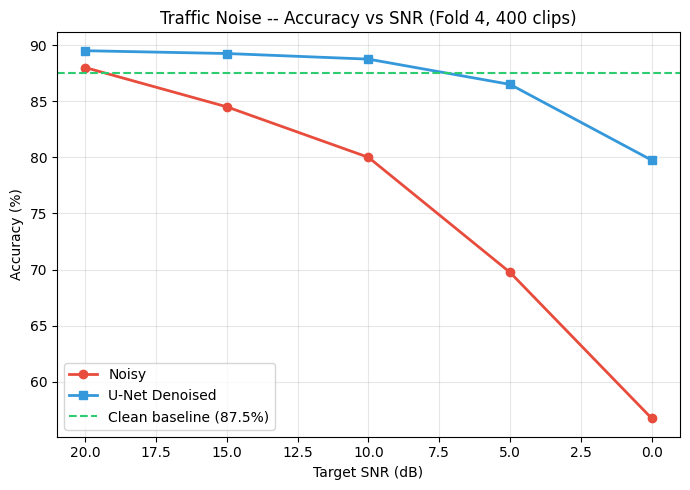

Saved -> /content/drive/MyDrive/DSP Project/traffic_denoiser_unet/results/traffic_unet_accuracy_vs_snr.png


In [17]:
import matplotlib.pyplot as plt

snr_sorted = sorted(TRAFFIC_SNR_EVAL, reverse=True)
sdf = summary_df.set_index('SNR_target').loc[snr_sorted]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(snr_sorted, sdf['acc_noisy'], marker='o', label='Noisy', color='#e74c3c', lw=2)
ax.plot(snr_sorted, sdf['acc_unet'],  marker='s', label='U-Net Denoised', color='#3498db', lw=2)
if _HAS_MMSE:
    ax.plot(snr_sorted, sdf['acc_mmse'], marker='^', label='MMSE-LSA', color='#9b59b6', lw=2)
ax.axhline(acc_clean, color='#2ecc71', ls='--', lw=1.5, label=f'Clean baseline ({acc_clean:.1f}%)')

ax.set_title(f'Traffic Noise -- Accuracy vs SNR (Fold {OUTER_TEST_FOLD}, {len(df_res)} clips)')
ax.set_xlabel('Target SNR (dB)')
ax.set_ylabel('Accuracy (%)')
ax.invert_xaxis()
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plot_path = str(OUT_RESULTS / "traffic_unet_accuracy_vs_snr.png")
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {plot_path}")


## Cell 15 — Spectrogram diff: clean vs noisy vs U-Net-denoised (sanity check)

Visual check on a handful of clips at one SNR -- look for whether the U-Net
preserves low-frequency signal energy (where traffic noise overlaps with ESC-50
content) while suppressing the traffic noise itself, compared to the over-/under-
suppression seen with MMSE-LSA/IMCRA.

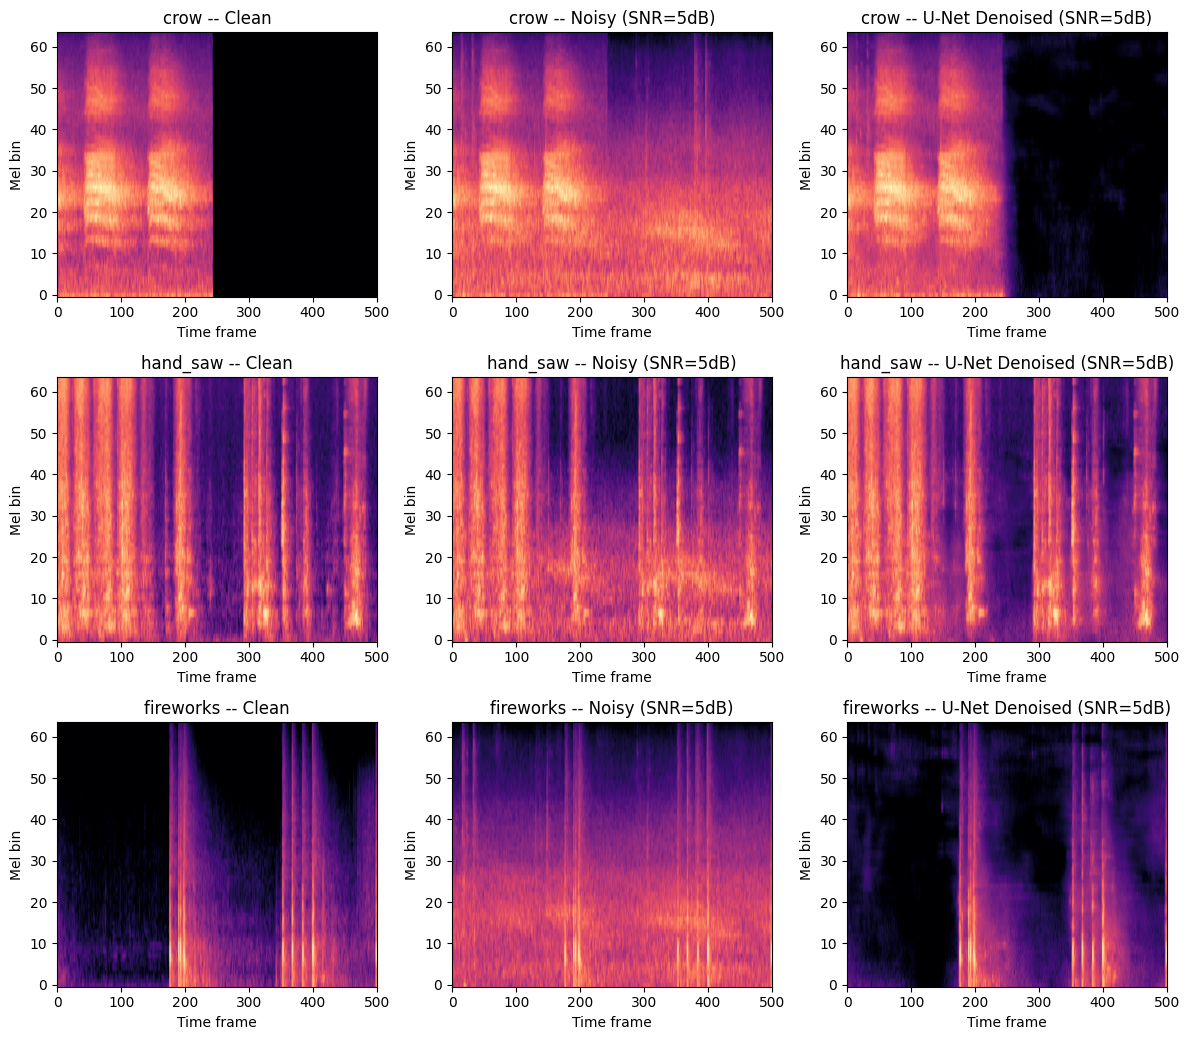

Saved -> /content/drive/MyDrive/DSP Project/traffic_denoiser_unet/results/traffic_unet_spectrogram_diagnostic.png


In [18]:
SNR_FOR_PLOT = 5    # pick one SNR to visualize
N_EXAMPLES   = 3

fig, axes = plt.subplots(N_EXAMPLES, 3, figsize=(12, 3.5 * N_EXAMPLES))
if N_EXAMPLES == 1:
    axes = axes[np.newaxis, :]

plot_rng = np.random.default_rng(SEED + 200)
sample_rows = df_test_outer.sample(n=N_EXAMPLES, random_state=SEED + 200).reset_index(drop=True)

for i, row in sample_rows.iterrows():
    wav_np = load_wav_np(row['file_path'])
    noisy  = add_real_noise(wav_np, SNR_FOR_PLOT, rng=plot_rng)
    denoised = unet_denoise(noisy)

    for j, (label, w) in enumerate([('Clean', wav_np), ('Noisy', noisy), ('U-Net Denoised', denoised)]):
        spec = wav_to_logmel(w)[0]   # (N_MELS, T)
        ax = axes[i, j]
        im = ax.imshow(spec, origin='lower', aspect='auto', cmap='magma')
        ax.set_title(f"{row['category']} -- {label}" + (f" (SNR={SNR_FOR_PLOT}dB)" if label != 'Clean' else ''))
        ax.set_xlabel('Time frame')
        ax.set_ylabel('Mel bin')

plt.tight_layout()
diag_path = str(OUT_RESULTS / "traffic_unet_spectrogram_diagnostic.png")
plt.savefig(diag_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved -> {diag_path}")
